# Layer 1: Statistical Process Control + Isolation Forest
## Early Warning Signal Detection — NASA ASRS 2018–2026

**Goal:** Flag incidents that are statistically anomalous in frequency (SPC) and/or behaviourally novel (Isolation Forest), then combine both signals into a 2×2 risk quadrant.

| Signal | Algorithm | Question answered |
| --- | --- | --- |
| SPC | STL decomposition + two-sided CUSUM | *Is this category occurring at an anomalous rate?* |
| Novelty | Isolation Forest (2018–2019 baseline) | *Does this incident look unlike normal operations?* |

The quadrant intersection (novel **and** anomalous frequency) is the early-warning zone.  
GNSS spoofing landed in RED before any official taxonomy category existed for it.

In [1]:
import sys
import os
sys.path.insert(0, '..')  # project root → enables `from src.X import ...`

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 110,
    'figure.figsize': (11, 4),
    'axes.spines.top': False,
    'axes.spines.right': False,
})

In [2]:
# Load Layer 1 enriched dataset (already computed by run_layer1.py)
asrs = pd.read_parquet('../outputs/data/asrs_layer1.parquet')
asrs['date'] = pd.to_datetime(asrs['date'], errors='coerce')

print(f"Corpus : {len(asrs):,} incidents")
print(f"Date   : {asrs['date'].min().strftime('%b %Y')} → {asrs['date'].max().strftime('%b %Y')}")
print(f"Columns: {asrs.shape[1]}")

# Layer 1 adds four columns to the raw dataset
layer1_cols = ['ACN', 'date', 'if_score', 'if_flag', 'spc_flag', 'quadrant']
asrs[[c for c in layer1_cols if c in asrs.columns]].head(5)

Corpus : 43,829 incidents
Date   : Jun 2002 → Mar 2026
Columns: 204


,ACN,date,if_score,if_flag,spc_flag,quadrant
0,1909753,2002-06-01,0.656395,0,0,GREEN
1,1823845,2012-07-01,0.493236,0,0,GREEN
2,2205580,2015-01-01,0.429186,0,0,GREEN
3,2224585,2015-03-01,0.496915,0,0,GREEN
4,1513871,2018-01-01,0.663787,0,0,GREEN


### The Dataset

43,829 incident reports filed voluntarily by pilots, controllers, and cabin crew.  
Each record has structured metadata (flight phase, anomaly category, aircraft operator) plus free-text narrative — the primary signal source for Layers 2–4.

**COVID dip** (2020): flight hours fell ~60% from March 2020. The Isolation Forest baseline is deliberately trained on **2018–2019 only** — including 2020 would corrupt the model's definition of "normal operations".

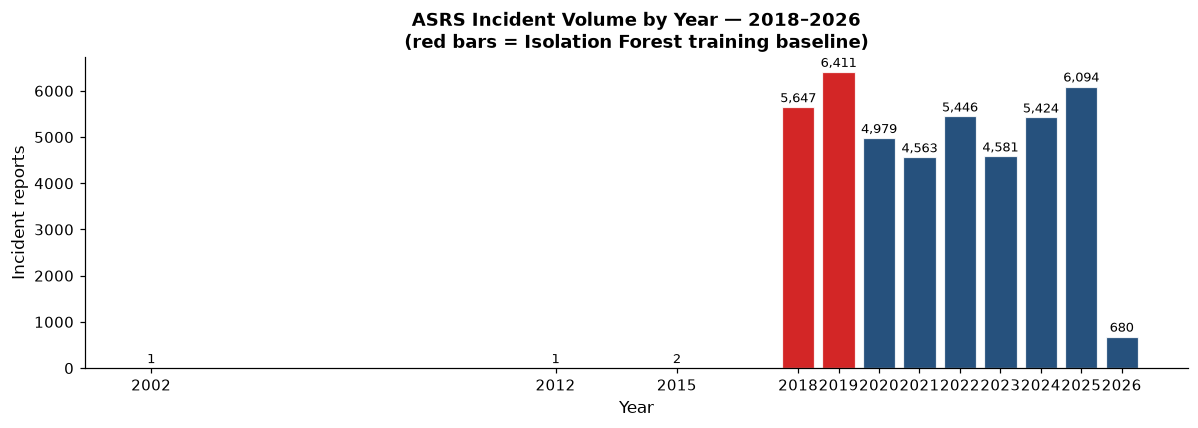

In [3]:
year_counts = asrs['date'].dt.year.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(year_counts.index, year_counts.values,
              color=['#cc0000' if y in [2018, 2019] else '#003366'
                     for y in year_counts.index],
              alpha=0.85, edgecolor='white', linewidth=0.8)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 40,
            f'{int(bar.get_height()):,}',
            ha='center', va='bottom', fontsize=8.5)

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Incident reports', fontsize=11)
ax.set_title(
    'ASRS Incident Volume by Year — 2018–2026\n'
    '(red bars = Isolation Forest training baseline)',
    fontsize=12, fontweight='bold'
)
ax.set_xticks(year_counts.index)
plt.tight_layout()

---
## Signal 1: Statistical Process Control (CUSUM)

**Why STL + CUSUM rather than raw CUSUM?**  
Aviation incident rates have a strong seasonal component (summer travel peaks, winter weather events). Running CUSUM directly on raw counts would fire false alarms every summer. STL decomposition removes the seasonal and trend components first; CUSUM then runs on the **residuals** — deviations from the expected seasonal pattern.

Parameters: `k = 0.5` (allowance, detects 1σ shifts), `h = 5.0` (control limit, ARL ≈ 500 in-control).

In [4]:
from src.spc import get_top_anomaly_categories

top_cats = get_top_anomaly_categories(asrs, top_n=15)
df_cats = pd.DataFrame({
    'Category': top_cats.index,
    'Incidents': top_cats.values,
    '% of corpus': (top_cats.values / len(asrs) * 100).round(1),
})
df_cats.index = range(1, len(df_cats) + 1)
df_cats

,Category,Incidents,% of corpus
1,Deviation / Discrepancy - Procedural Published...,24476,55.8
2,Aircraft Equipment Problem Critical,11465,26.2
3,Deviation / Discrepancy - Procedural Clearance,8780,20.0
4,ATC Issue All Types,7097,16.2
5,Aircraft Equipment Problem Less Severe,6842,15.6
6,Deviation / Discrepancy - Procedural FAR,5271,12.0
7,Conflict NMAC,4194,9.6
8,Inflight Event / Encounter CFTT / CFIT,3942,9.0
9,Inflight Event / Encounter Weather / Turbulence,3664,8.4
10,Ground Event / Encounter Loss Of Aircraft Control,2930,6.7


In [5]:
# Run SPC live on the top category to show the pipeline works end-to-end
from src.spc import run_spc_pipeline

top_cat = top_cats.index[0]
result = run_spc_pipeline(asrs, category_value=top_cat)

if result:
    print(f"Category : {top_cat}")
    print(f"Months   : {len(result['monthly_counts'])}")
    print(f"Mean/mo  : {result['monthly_counts'].mean():.1f} incidents")
    print(f"Alarms   : {len(result['alarms'])}")
    if result['alarms']:
        alarm_strs = [a.strftime('%b %Y') for a in result['alarms'][:6]]
        print(f"First alarms: {', '.join(alarm_strs)}")
else:
    print(f"Category '{top_cat}' did not pass minimum SPC requirements")

2026-06-25 12:59:09 | INFO     | src.spc | 'Deviation / Discrepancy - Procedural Published Material / Policy': 99 months, mean 247.2/month, 8 CUSUM alarms
Category : Deviation / Discrepancy - Procedural Published Material / Policy
Months   : 99
Mean/mo  : 247.2 incidents
Alarms   : 8
First alarms: Oct 2019, Nov 2019, Dec 2019, Jan 2020, Feb 2020, Jun 2022


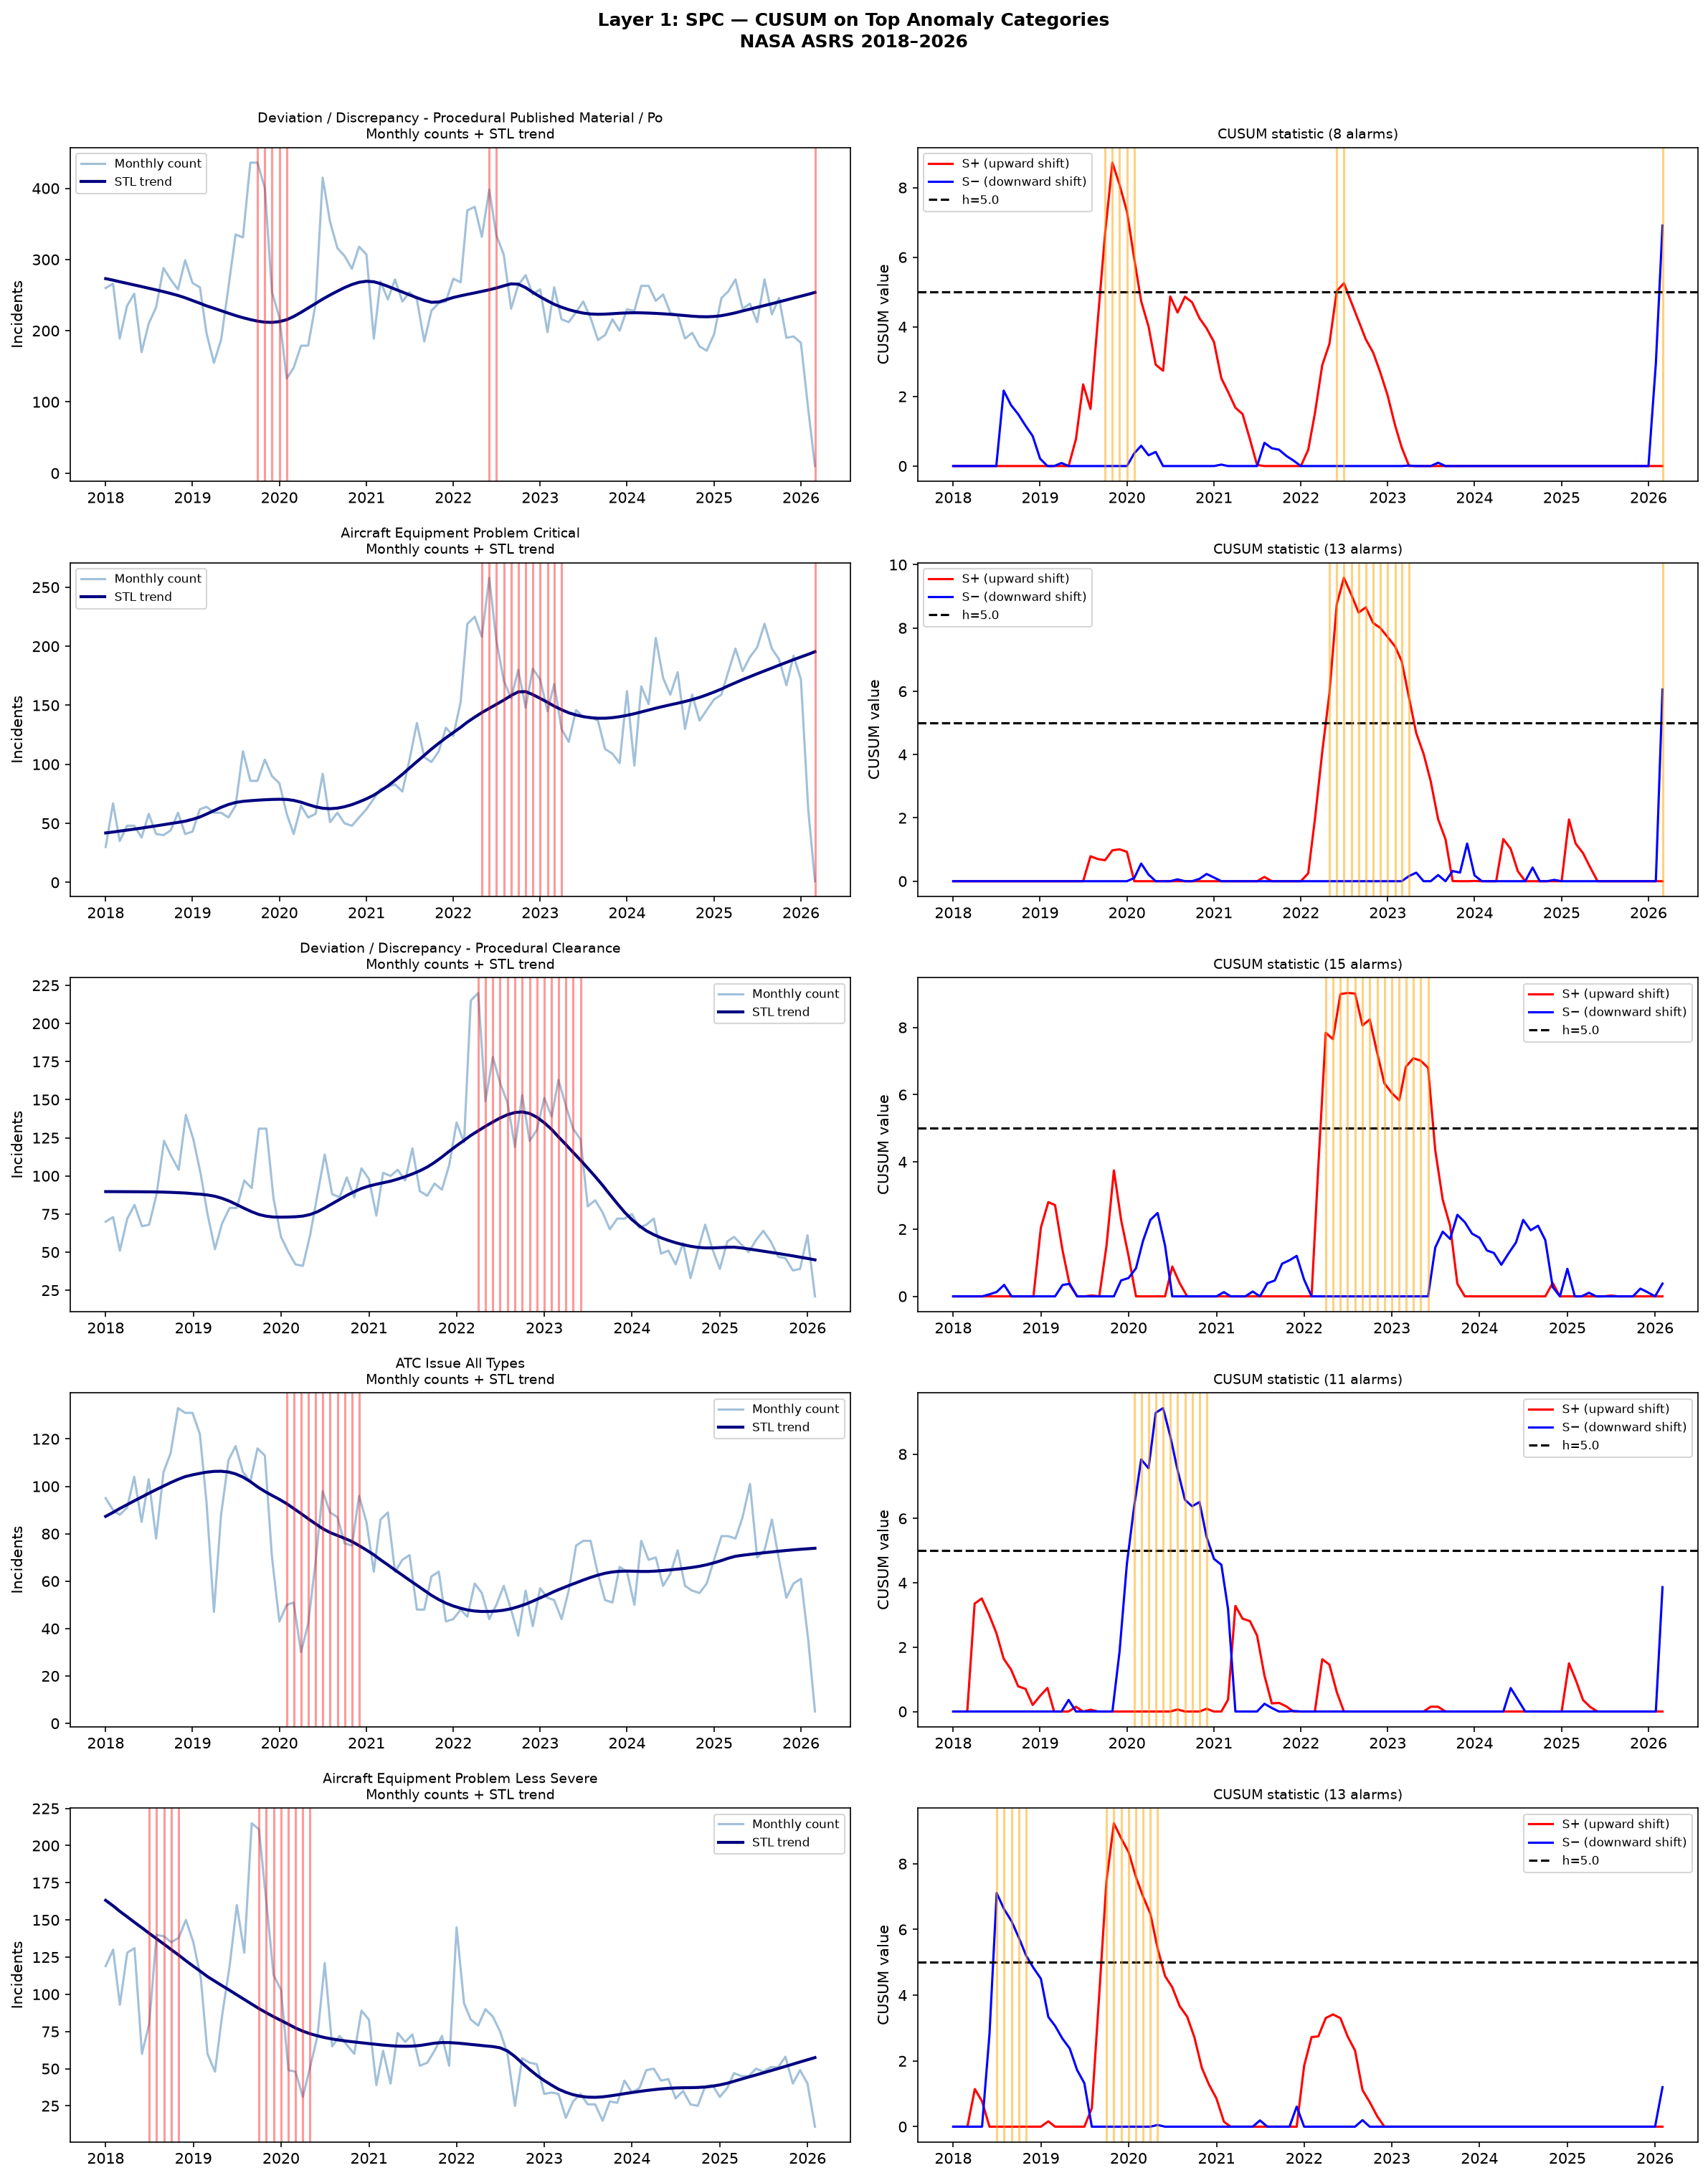

In [6]:
# Full SPC multi-panel chart (all top categories, saved by run_layer1.py)
display(Image('../outputs/figures/layer1_spc_cusum.png'))

In [7]:
# How many incident-months were flagged by SPC across the corpus?
spc_flagged = asrs[asrs['spc_flag'] == 1]
print(f"SPC-flagged incidents : {len(spc_flagged):,} ({len(spc_flagged)/len(asrs)*100:.1f}% of corpus)")

# Which months had the most SPC flags?
top_alarm_months = (
    spc_flagged
    .groupby(spc_flagged['date'].dt.to_period('M'))['ACN'].count()
    .sort_values(ascending=False)
    .head(10)
)
print("\nTop 10 SPC alarm months:")
print(top_alarm_months.to_string())

SPC-flagged incidents : 15,588 (35.6% of corpus)

Top 10 SPC alarm months:
date
2019-10    685
2019-11    655
2020-07    617
2022-06    557
2018-10    543
2020-08    531
2018-09    519
2018-11    519
2022-04    506
2022-05    503
Freq: M


---
## Signal 2: Isolation Forest

**Behavioural novelty** — does this incident resemble normal operations?

Features: flight phase, aircraft operator, detector, result, primary problem, month, year.  
Training set: **2018–2019 only** (12,058 pre-COVID baseline records).  
Contamination: `0.05` — the top 5% most isolated incidents are flagged.

The IF score is normalised to [0, 1] where **1 = most anomalous**.  
An incident can score high on IF without triggering SPC — it's behaviourally unusual even if the category frequency is normal (e.g., a novel equipment failure type seen only a few times per year).

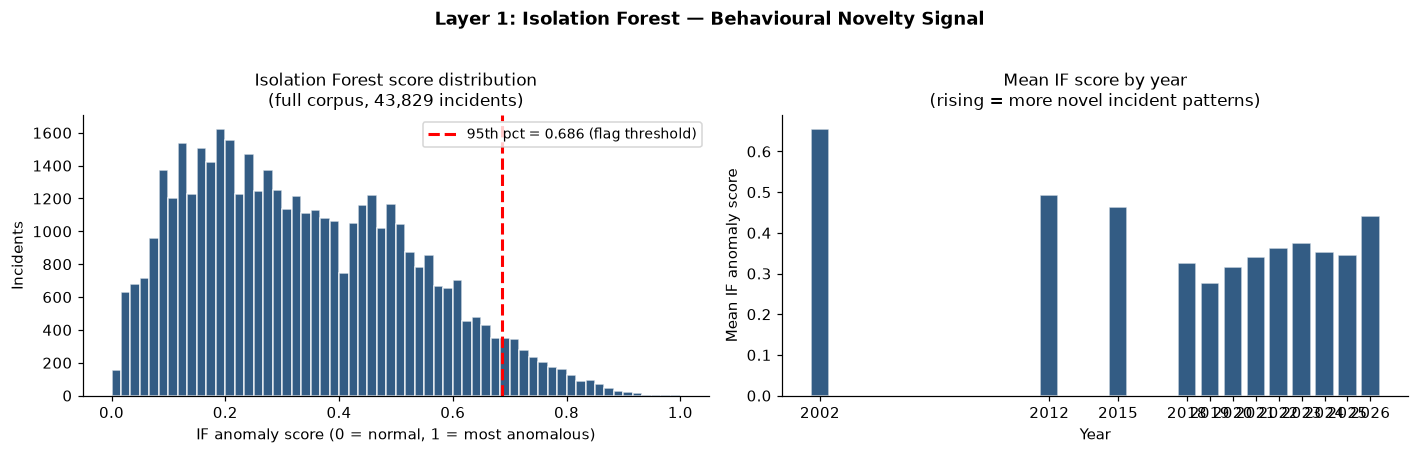

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: IF score distribution across full corpus
axes[0].hist(asrs['if_score'], bins=60, color='#003366', alpha=0.8, edgecolor='white')
threshold_95 = asrs['if_score'].quantile(0.95)
axes[0].axvline(threshold_95, color='red', linestyle='--', linewidth=2,
                label=f'95th pct = {threshold_95:.3f} (flag threshold)')
axes[0].set_xlabel('IF anomaly score (0 = normal, 1 = most anomalous)', fontsize=10)
axes[0].set_ylabel('Incidents', fontsize=10)
axes[0].set_title('Isolation Forest score distribution\n(full corpus, 43,829 incidents)', fontsize=11)
axes[0].legend(fontsize=9)

# Right: IF score by year — does novelty shift over time?
yearly_if = asrs.groupby(asrs['date'].dt.year)['if_score'].mean()
axes[1].bar(yearly_if.index, yearly_if.values, color='#003366', alpha=0.8, edgecolor='white')
axes[1].set_xlabel('Year', fontsize=10)
axes[1].set_ylabel('Mean IF anomaly score', fontsize=10)
axes[1].set_title('Mean IF score by year\n(rising = more novel incident patterns)', fontsize=11)
axes[1].set_xticks(yearly_if.index)

plt.suptitle('Layer 1: Isolation Forest — Behavioural Novelty Signal',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()

---
## Combining the Signals: 2×2 Risk Quadrant

Each incident is assigned to one quadrant based on two binary flags:

| Quadrant | SPC flag | IF flag | Interpretation |
| --- | --- | --- | --- |
| **RED** | ✓ anomalous freq | ✓ novel | Highest priority — new threat class emerging |
| **ORANGE** | ✓ anomalous freq | ✗ known | Known category spiking — investigate cause |
| **YELLOW** | ✗ normal freq | ✓ novel | Watch — unusual but not yet at scale |
| **GREEN** | ✗ normal freq | ✗ known | Business as usual |

**GNSS spoofing in 2023–2024 lands in RED** because it was behaviourally novel (IF flagged it as unlike anything in the 2018–2019 baseline) at the same time that SPC CUSUM fired on the narrative-derived GNSS signal.

In [10]:
# Quadrant breakdown
counts = asrs['quadrant'].value_counts()
order = ['RED', 'ORANGE', 'YELLOW', 'GREEN']
summary = pd.DataFrame({
    'Quadrant': order,
    'Incidents': [counts.get(q, 0) for q in order],
    'Pct of corpus': [f"{counts.get(q, 0)/len(asrs)*100:.1f}%" for q in order],
    'Priority': ['Immediate', 'High', 'Monitor', 'Routine'],
})
summary.index = range(1, len(summary) + 1)
print(f"Total incidents: {len(asrs):,}")
summary

Total incidents: 43,829


,Quadrant,Incidents,Pct of corpus,Priority
1,RED,818,1.9%,Immediate
2,ORANGE,14770,33.7%,High
3,YELLOW,1374,3.1%,Monitor
4,GREEN,26867,61.3%,Routine


In [ ]:
display(Image('../outputs/figures/2x2_quadrant.png'))

---
## Headline Finding: GNSS Spoofing Emergence

The clearest validation of the early-warning approach: **GNSS spoofing/jamming was near-zero in the 2018–2022 baseline period** and then rose sharply from late 2023, triggering a CUSUM alarm.

This signal was extracted purely from free-text pilot narratives using a regex filter — before IATA had a dedicated taxonomy category for this threat.  
Layer 2 (BERTopic) will independently rediscover this as a distinct semantic cluster, validating the Layer 1 SPC alarm from a completely different analytical approach.

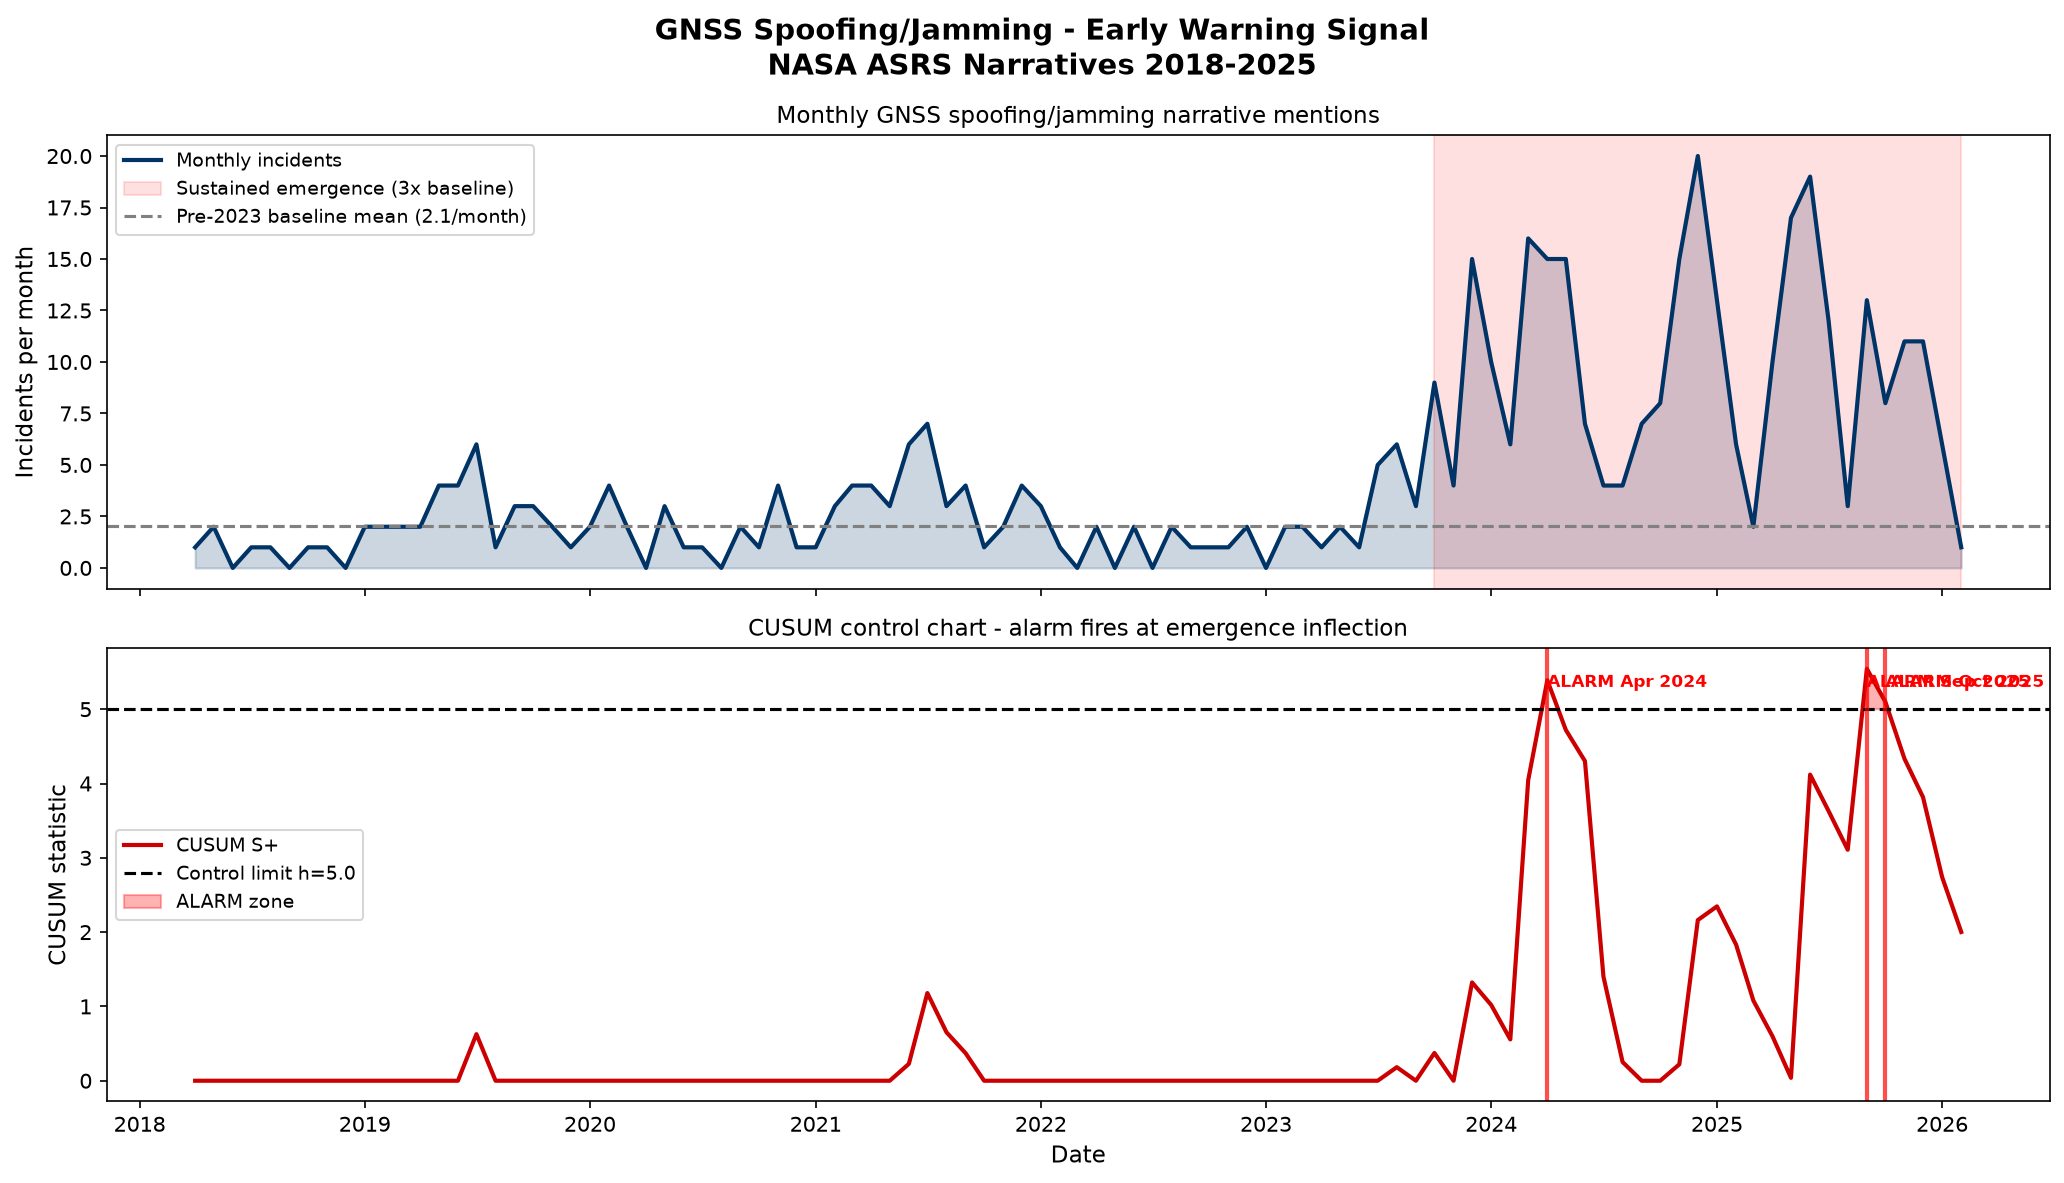

In [11]:
display(Image('../outputs/figures/gnss_emergence.png'))

In [12]:
# Year-by-year GNSS incident count to show the inflection numerically
gnss_mask = asrs['full_narrative'].astype(str).str.lower().str.contains(
    r'spoofing|jamming|gps.{0,20}denial|gnss.{0,20}denial|'
    r'gps.{0,20}interference|navigation.{0,20}interference',
    regex=True, na=False
)
gnss_by_year = (
    asrs[gnss_mask]
    .groupby(asrs[gnss_mask]['date'].dt.year)['ACN'].count()
    .rename('GNSS incidents')
)
total_by_year = asrs.groupby(asrs['date'].dt.year)['ACN'].count().rename('Total incidents')
gnss_summary = pd.concat([gnss_by_year, total_by_year], axis=1).fillna(0).astype(int)
gnss_summary['Rate (per 1k)'] = (gnss_summary['GNSS incidents'] / gnss_summary['Total incidents'] * 1000).round(2)

print(f"Total GNSS-related incidents: {gnss_mask.sum():,} ({gnss_mask.mean()*100:.2f}% of corpus)")
gnss_summary

Total GNSS-related incidents: 426 (0.97% of corpus)


,GNSS incidents,Total incidents,Rate (per 1k)
date,,,
2018,7,5647,1.24
2019,32,6411,4.99
2020,21,4979,4.22
2021,42,4563,9.20
2022,15,5446,2.75
2023,50,4581,10.91
2024,127,5424,23.41
2025,125,6094,20.51
2026,7,680,10.29


---
## Layer 1 → Layer 2 Handoff

Layer 1 outputs four new columns that travel into every subsequent layer:

| Column | Type | Used by |
| --- | --- | --- |
| `if_score` | float [0,1] | Layer 3 risk scoring, Layer 4 RAG metadata |
| `if_flag` | int {0,1} | Quadrant assignment |
| `spc_flag` | int {0,1} | Quadrant assignment |
| `quadrant` | str RED/ORANGE/YELLOW/GREEN | Layer 3 export filter, Layer 4 RAG index |

**Layer 2 question:** *What are pilots actually talking about, and how have those topics shifted?*  
BERTopic will run on the full 43,829 narrative corpus and independently confirm the GNSS emergence signal detected here by SPC — as two distinct semantic clusters (GPS spoofing and 5G/altimeter interference), distinguished purely by narrative semantics.